# FDPIS — Notebook 2: Primary Delay Model (Layer 3)

**Run `fdpis_1_data_prep.ipynb` first.**

### Question
Given only what's knowable hours before departure, which flights carry the most structural
risk of a **primary** delay? Cascade delays are Layer 4's job and are excluded here.

### Headline metric: precision@1%, not F1
The deliverable is a ranked morning briefing, not a binary alarm. An OCC can review 20 flights
at 5am; it cannot act on 20,000 flagged ones. So what matters is whether the *top* of the
ranking is dense with real delays — that's precision@k. F1 and AUC are reported alongside.

### Fixes from the previous attempt
- Split on `FL_DATE`, not `DAY_OF_MONTH` (which silently breaks across multiple months)
- Bayesian-smoothed target encoding instead of raw group means
- Logistic regression gets imputation + scaling + one-hot (it can't take NaN; trees can)
- `DAY_OF_MONTH` never used as a feature — it memorises specific dates

## 1 — Imports and load

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix)

pd.set_option('display.max_columns', 80)

df = pd.read_parquet('data/processed.parquet')
print(f'Loaded {len(df):,} rows')
print(f'Span: {df["FL_DATE"].min().date()} to {df["FL_DATE"].max().date()} '
      f'({df["FL_DATE"].nunique()} days)')

Loaded 1,718,426 rows
Span: 2025-01-01 to 2025-07-31 (92 days)


## 2 — Isolate primary delays

Drop flights where BTS attributed any delay to a late incoming aircraft. Those are cascades.

Note this makes the task *harder*, not easier: cascade delays are the mechanically predictable
ones (tight turnaround → downstream delay). What's left is the genuinely difficult residue.
Any comparison against a model trained on all flights must account for this.

In [17]:
TARGET = 'DEP_DEL15'

before = len(df)
primary = df[df['LATE_AIRCRAFT_DELAY'].fillna(0) == 0].copy()
primary = primary.dropna(subset=[TARGET]).copy()
primary[TARGET] = primary[TARGET].astype(int)

print(f'Removed {before - len(primary):,} cascade-attributed / null-target rows')
print(f'Remaining: {len(primary):,}')
print(f'Positive rate: {100*primary[TARGET].mean():.1f}%')
print(f'Majority-class baseline accuracy: {100*(1-primary[TARGET].mean()):.1f}%')

Removed 195,575 cascade-attributed / null-target rows
Remaining: 1,522,851
Positive rate: 12.8%
Majority-class baseline accuracy: 87.2%


## 3 — Date-based split

Splitting on actual dates, so this stays correct with any number of months.
(`DAY_OF_MONTH <= 21` would put January 27 *and* February 27 in test — training on February
to predict January. Time-series data must never be shuffled or split on a recycled key.)

In [18]:
dates = np.sort(primary['FL_DATE'].unique())
n = len(dates)
train_end = dates[int(n * 0.70)]
val_end   = dates[int(n * 0.85)]

train = primary[primary['FL_DATE'] <= train_end].copy()
val   = primary[(primary['FL_DATE'] > train_end) & (primary['FL_DATE'] <= val_end)].copy()
test  = primary[primary['FL_DATE'] > val_end].copy()

for nm, d in [('Train', train), ('Val', val), ('Test', test)]:
    print(f'{nm:<6} {len(d):>8,} rows | {d["FL_DATE"].min().date()} to {d["FL_DATE"].max().date()} '
          f'| positive rate {100*d[TARGET].mean():.1f}%')

shift = test[TARGET].mean() - train[TARGET].mean()
print(f'\nTrain->test positive-rate shift: {100*shift:+.1f} pts')
if abs(shift) > 0.02:
    print('WARNING: large distribution shift. Test period had a different delay regime')
    print('(likely weather). More months of data is the fix.')

Train  1,067,167 rows | 2025-01-01 to 2025-07-04 | positive rate 11.3%
Val     232,583 rows | 2025-07-05 to 2025-07-18 | positive rate 17.0%
Test    223,101 rows | 2025-07-19 to 2025-07-31 | positive rate 15.6%

Train->test positive-rate shift: +4.3 pts
(likely weather). More months of data is the fix.


## 4 — Bayesian-smoothed target encoding

A route with 3 historical flights and 2 delays has a raw mean of 0.67 — pure noise.
Smoothing shrinks small-sample groups toward the global rate:

```
smoothed = (count * group_mean + m * global_mean) / (count + m)
```

With `m=50`, a group needs ~50 observations before its own mean dominates.

**Computed on train only**, then mapped onto val/test. Computing these across the full
dataset would leak test outcomes backwards into the features.

In [19]:
SMOOTHING_M = 50
global_rate = train[TARGET].mean()

ENCODINGS = {
    'CARRIER':        ['OP_UNIQUE_CARRIER'],
    'ORIGIN':         ['ORIGIN'],
    'DEST':           ['DEST'],
    'ROUTE':          ['ORIGIN','DEST'],
    'ORIGIN_HOUR':    ['ORIGIN','DEP_HOUR'],
    'CARRIER_ORIGIN': ['OP_UNIQUE_CARRIER','ORIGIN'],
    'CARRIER_HOUR':   ['OP_UNIQUE_CARRIER','DEP_HOUR'],
    'DOW_HOUR':       ['DAY_OF_WEEK','DEP_HOUR'],
}

lookups = {}
for name, keys in ENCODINGS.items():
    st = train.groupby(keys)[TARGET].agg(['mean','count'])
    lookups[name] = ((st['count']*st['mean'] + SMOOTHING_M*global_rate)
                     / (st['count'] + SMOOTHING_M))

def apply_encodings(d):
    d = d.copy()
    for name, keys in ENCODINGS.items():
        idx = pd.MultiIndex.from_arrays([d[k] for k in keys]) if len(keys) > 1 else d[keys[0]]
        d[f'ENC_{name}'] = idx.map(lookups[name]).astype(float).fillna(global_rate)
    return d

train, val, test = apply_encodings(train), apply_encodings(val), apply_encodings(test)
print(f'Global train delay rate: {global_rate:.4f}')
print('Encodings added:', [f'ENC_{k}' for k in ENCODINGS])

Global train delay rate: 0.1126
Encodings added: ['ENC_CARRIER', 'ENC_ORIGIN', 'ENC_DEST', 'ENC_ROUTE', 'ENC_ORIGIN_HOUR', 'ENC_CARRIER_ORIGIN', 'ENC_CARRIER_HOUR', 'ENC_DOW_HOUR']


## 5 — Cyclical time encoding

As an integer, hour 23 and hour 0 look 23 apart. Projected onto a circle they're adjacent,
which is what they actually are.

In [20]:
def add_cyclical(d):
    d = d.copy()
    d['DEP_HOUR_SIN'] = np.sin(2*np.pi*d['DEP_HOUR']/24)
    d['DEP_HOUR_COS'] = np.cos(2*np.pi*d['DEP_HOUR']/24)
    d['ARR_HOUR_SIN'] = np.sin(2*np.pi*d['ARR_HOUR']/24)
    d['ARR_HOUR_COS'] = np.cos(2*np.pi*d['ARR_HOUR']/24)
    d['DOW_SIN'] = np.sin(2*np.pi*d['DAY_OF_WEEK']/7)
    d['DOW_COS'] = np.cos(2*np.pi*d['DAY_OF_WEEK']/7)
    return d

train, val, test = add_cyclical(train), add_cyclical(val), add_cyclical(test)
print('Cyclical features added.')

Cyclical features added.


## 6 — Feature groups and leakage audit

Every feature below is knowable from the published schedule hours ahead of departure.

**Excluded, and why:** `DEP_TIME`, `DEP_DELAY`, `TAXI_OUT`, `WHEELS_OFF`, `WHEELS_ON`,
`TAXI_IN`, `ARR_TIME`, `ARR_DELAY`, `ARR_DEL15`, `ACTUAL_ELAPSED_TIME`, `AIR_TIME` and all
five cause codes happen at or after departure. `PREV_ARR_DELAY` is Layer 4's input and often
isn't knowable yet at a 3–6 hour horizon. `DAY_OF_MONTH` memorises specific dates.

In [21]:
GROUPS = {
    'A_schedule':    ['CRS_DEP_TIME','CRS_ARR_TIME','DEP_HOUR','ARR_HOUR',
                      'CRS_ELAPSED_TIME','DISTANCE','SPEED_PROXY','DAY_OF_WEEK','IS_WEEKEND'],
    'B_cyclical':    ['DEP_HOUR_SIN','DEP_HOUR_COS','ARR_HOUR_SIN','ARR_HOUR_COS',
                      'DOW_SIN','DOW_COS'],
    'C_categorical': ['OP_UNIQUE_CARRIER','ORIGIN','DEST'],
    'D_encodings':   [f'ENC_{k}' for k in ENCODINGS],
    'E_congestion':  ['ORIGIN_HOUR_DEPARTURES','DEST_HOUR_ARRIVALS','ORIGIN_DAY_DEPARTURES',
                      'CARRIER_ORIGIN_FLIGHTS','CARRIER_ORIGIN_SHARE'],
    'F_rotation':    ['LEG_NUM','TAIL_LEGS_TODAY','LEG_FRACTION','IS_LAST_LEG',
                      'MINUTES_INTO_TAIL_DAY','SCHEDULED_BUFFER_MIN','AVAILABLE_SLACK',
                      'IS_TIGHT_TURNAROUND','LONG_GROUND_TIME'],
}

CAT_COLS = ['OP_UNIQUE_CARRIER','ORIGIN','DEST']
ALL_FEATURES = [f for g in GROUPS.values() for f in g]

FORBIDDEN = ['DEP_TIME','DEP_DELAY','DEP_DELAY_NEW','DEP_DEL15','TAXI_OUT','WHEELS_OFF',
             'WHEELS_ON','TAXI_IN','ARR_TIME','ARR_DELAY','ARR_DELAY_NEW','ARR_DEL15',
             'ACTUAL_ELAPSED_TIME','AIR_TIME','CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY',
             'SECURITY_DELAY','LATE_AIRCRAFT_DELAY','CANCELLATION_CODE','PREV_ARR_DELAY',
             'DAY_OF_MONTH','PREDICTED_PROP_MIN','IS_REACTIONARY']

leaks = [f for f in ALL_FEATURES if f in FORBIDDEN]
if leaks:
    raise ValueError(f'LEAKAGE: {leaks}')
absent = [f for f in ALL_FEATURES if f not in train.columns]
if absent:
    raise ValueError(f'Missing from data: {absent}')

print(f'{len(ALL_FEATURES)} features across {len(GROUPS)} groups — leakage check passed.')
for g, f in GROUPS.items():
    print(f'  {g:<15} {len(f)}')

40 features across 6 groups — leakage check passed.
  A_schedule      9
  B_cyclical      6
  C_categorical   3
  D_encodings     8
  E_congestion    5
  F_rotation      9


## 7 — Matrix prep and evaluation helper

In [22]:
cat_types = {c: pd.CategoricalDtype(categories=sorted(train[c].dropna().unique()))
             for c in CAT_COLS}

def prep(d, feats):
    X = d[feats].copy()
    for c in CAT_COLS:
        if c in X.columns:
            X[c] = X[c].astype(cat_types[c])
    return X

y_train, y_val, y_test = train[TARGET], val[TARGET], test[TARGET]
scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

def precision_at_k(y_true, prob, k_pct):
    k = max(int(len(prob) * k_pct / 100), 1)
    top = np.argsort(-prob)[:k]
    return np.asarray(y_true)[top].mean()

def evaluate(name, y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    return {
        'model': name,
        'auc':      round(roc_auc_score(y_true, prob), 4),
        'pr_auc':   round(average_precision_score(y_true, prob), 4),
        'precision':round(precision_score(y_true, pred, zero_division=0), 3),
        'recall':   round(recall_score(y_true, pred), 3),
        'f1':       round(f1_score(y_true, pred), 3),
        'p@1%':     round(precision_at_k(y_true, prob, 1), 3),
        'p@5%':     round(precision_at_k(y_true, prob, 5), 3),
        'p@10%':    round(precision_at_k(y_true, prob, 10), 3),
    }
print('Helpers ready.')

scale_pos_weight: 7.88
Helpers ready.


## 8 — Feature ablation

Adds one group at a time and measures the marginal gain. This is the evidence for which
features actually earn their place — the table to show Anuradha.

In [24]:
def quick_xgb(feats):
    has_cat = any(c in feats for c in CAT_COLS)
    m = xgb.XGBClassifier(
        n_estimators=400, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        scale_pos_weight=scale_pos_weight, enable_categorical=has_cat,
        tree_method='hist', eval_metric='auc', early_stopping_rounds=40,
        random_state=42, n_jobs=-1)
    m.fit(prep(train, feats), y_train,
          eval_set=[(prep(val, feats), y_val)], verbose=False)
    return m, m.predict_proba(prep(test, feats))[:, 1]

rows, cumulative, prev_auc = [], [], None
for gname, gfeats in GROUPS.items():
    cumulative = cumulative + gfeats
    _, prob = quick_xgb(cumulative)
    r = evaluate(gname, y_test, prob)
    r['n_feat'] = len(cumulative)
    r['auc_gain'] = '' if prev_auc is None else round(r['auc'] - prev_auc, 4)
    prev_auc = r['auc']
    rows.append(r)
    print(f"{gname:<15} n={len(cumulative):<3} AUC={r['auc']:.4f}  p@1%={r['p@1%']:.3f}")

ablation = pd.DataFrame(rows)[['model','n_feat','auc','auc_gain','pr_auc','f1','p@1%','p@5%','p@10%']]
print()
print(ablation.to_string(index=False))

A_schedule      n=9   AUC=0.6357  p@1%=0.280
B_cyclical      n=15  AUC=0.6385  p@1%=0.316
C_categorical   n=18  AUC=0.6519  p@1%=0.374
D_encodings     n=26  AUC=0.6388  p@1%=0.355
E_congestion    n=31  AUC=0.6410  p@1%=0.366
F_rotation      n=40  AUC=0.6777  p@1%=0.779

        model  n_feat    auc auc_gain  pr_auc    f1  p@1%  p@5%  p@10%
   A_schedule       9 0.6357           0.2275 0.322 0.280 0.277  0.265
   B_cyclical      15 0.6385   0.0028  0.2345 0.321 0.316 0.303  0.279
C_categorical      18 0.6519   0.0134  0.2476 0.330 0.374 0.314  0.293
  D_encodings      26 0.6388  -0.0131  0.2400 0.319 0.355 0.309  0.290
 E_congestion      31 0.6410   0.0022  0.2420 0.322 0.366 0.313  0.293
   F_rotation      40 0.6777   0.0367  0.3239 0.348 0.779 0.456  0.371


## 9 — Model comparison

Six models. Logistic regression needs imputation, scaling and one-hot encoding — it cannot
accept NaN, while tree models handle it natively. That mismatch broke the previous run.

Expect linear to lose to the trees. Run it anyway: it's the interpretable baseline, and its
coefficients translate into plain English for an operations audience.

In [26]:
pip install lightgbm

  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
Using cached lightgbm-4.7.0-py3-none-win_amd64.whl (1.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [27]:
NUM_COLS = [c for c in ALL_FEATURES if c not in CAT_COLS]
Xtr, Xv, Xte = prep(train, ALL_FEATURES), prep(val, ALL_FEATURES), prep(test, ALL_FEATURES)

def to_numeric(X):
    Xn = X.copy()
    for c in CAT_COLS:
        Xn[c] = Xn[c].cat.codes
    return Xn

results = []

# --- Logistic regression ---
logreg = Pipeline([
    ('prep', ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                          ('scale', StandardScaler())]), NUM_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=100), CAT_COLS),
    ])),
    ('clf', LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced')),
])
logreg.fit(Xtr, y_train)
results.append(evaluate('LogisticRegression', y_test, logreg.predict_proba(Xte)[:,1]))
print('LogisticRegression done')

# --- XGBoost ---
xgb_m = xgb.XGBClassifier(
    n_estimators=800, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    scale_pos_weight=scale_pos_weight, enable_categorical=True, tree_method='hist',
    eval_metric='auc', early_stopping_rounds=50, random_state=42, n_jobs=-1)
xgb_m.fit(Xtr, y_train, eval_set=[(Xv, y_val)], verbose=False)
prob_xgb = xgb_m.predict_proba(Xte)[:,1]
results.append(evaluate('XGBoost', y_test, prob_xgb))
print(f'XGBoost done (best iter {xgb_m.best_iteration})')

# --- RandomForest ---
rf = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=20,
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(to_numeric(Xtr).fillna(-1), y_train)
results.append(evaluate('RandomForest', y_test, rf.predict_proba(to_numeric(Xte).fillna(-1))[:,1]))
print('RandomForest done')

# --- HistGradientBoosting ---
hgb = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05, max_depth=7,
                                     class_weight='balanced', random_state=42)
hgb.fit(to_numeric(Xtr), y_train)
prob_hgb = hgb.predict_proba(to_numeric(Xte))[:,1]
results.append(evaluate('HistGradientBoosting', y_test, prob_hgb))
print('HistGradientBoosting done')

# --- LightGBM ---
prob_lgb = None
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMClassifier(n_estimators=800, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
        random_state=42, n_jobs=-1, verbose=-1)
    lgbm.fit(to_numeric(Xtr), y_train)
    prob_lgb = lgbm.predict_proba(to_numeric(Xte))[:,1]
    results.append(evaluate('LightGBM', y_test, prob_lgb))
    print('LightGBM done')
except ImportError:
    print('LightGBM not installed — pip install lightgbm')

# --- Blend ---
parts = [p for p in [prob_xgb, prob_hgb, prob_lgb] if p is not None]
results.append(evaluate('Blend (soft vote)', y_test, np.mean(parts, axis=0)))

# --- Baseline ---
base = y_test.mean()
results.append({'model':'Majority baseline','auc':0.5,'pr_auc':round(base,4),
                'precision':round(base,3),'recall':1.0,'f1':round(2*base/(1+base),3),
                'p@1%':round(base,3),'p@5%':round(base,3),'p@10%':round(base,3)})

comparison = pd.DataFrame(results).sort_values('auc', ascending=False)
print()
print(comparison.to_string(index=False))
print(f'\nBase delay rate in test: {base:.3f} — p@1% divided by this is the lift.')

LogisticRegression done
XGBoost done (best iter 125)
RandomForest done
HistGradientBoosting done
LightGBM done

               model    auc  pr_auc  precision  recall    f1  p@1%  p@5%  p@10%
   Blend (soft vote) 0.6819  0.3267      0.252   0.580 0.351 0.781 0.459  0.374
        RandomForest 0.6812  0.3255      0.261   0.532 0.350 0.763 0.454  0.373
            LightGBM 0.6801  0.3235      0.249   0.585 0.349 0.768 0.455  0.370
HistGradientBoosting 0.6791  0.3202      0.248   0.587 0.349 0.760 0.450  0.368
             XGBoost 0.6777  0.3239      0.253   0.561 0.348 0.779 0.456  0.371
  LogisticRegression 0.6534  0.2516      0.239   0.524 0.328 0.380 0.331  0.310
   Majority baseline 0.5000  0.1561      0.156   1.000 0.270 0.156 0.156  0.156

Base delay rate in test: 0.156 — p@1% divided by this is the lift.


## 10 — Logistic regression coefficients

The interpretability payoff. Positive coefficient = raises the odds of delay.
These translate into sentences an operations director can act on.

In [28]:
ohe = logreg.named_steps['prep'].named_transformers_['cat']
names = list(NUM_COLS) + list(ohe.get_feature_names_out(CAT_COLS))
coef = pd.DataFrame({'feature': names, 'coef': logreg.named_steps['clf'].coef_[0]})
coef['abs'] = coef['coef'].abs()
coef['odds_ratio'] = np.exp(coef['coef']).round(3)

print('Top 15 delay-increasing factors:')
print(coef.nlargest(15, 'coef')[['feature','coef','odds_ratio']].to_string(index=False))
print()
print('Top 10 delay-decreasing factors:')
print(coef.nsmallest(10, 'coef')[['feature','coef','odds_ratio']].to_string(index=False))

Top 15 delay-increasing factors:
     feature     coef  odds_ratio
  ORIGIN_PHX 0.558296       1.748
  ORIGIN_ORD 0.549854       1.733
  ORIGIN_DEN 0.545075       1.725
  ORIGIN_LAX 0.522224       1.686
  ORIGIN_CLT 0.492231       1.636
  ORIGIN_SFO 0.483706       1.622
  ORIGIN_DFW 0.469631       1.599
    DEST_LRD 0.425018       1.530
    DEST_MLU 0.392452       1.481
  ORIGIN_DCA 0.375969       1.456
  ORIGIN_LAS 0.373642       1.453
  ORIGIN_SEA 0.371167       1.449
  ORIGIN_SLC 0.366440       1.443
CRS_DEP_TIME 0.365193       1.441
    DEST_STT 0.334820       1.398

Top 10 delay-decreasing factors:
   feature      coef  odds_ratio
ORIGIN_ASE -0.916659       0.400
  DEST_SUN -0.517454       0.596
  DEP_HOUR -0.470496       0.625
ORIGIN_KTN -0.436229       0.646
ORIGIN_BIS -0.420405       0.657
ORIGIN_ITO -0.376216       0.686
ORIGIN_TVC -0.350051       0.705
ORIGIN_PSG -0.348005       0.706
ORIGIN_ABE -0.310463       0.733
ORIGIN_SBN -0.310305       0.733


## 11 — XGBoost feature importance

               feature  importance
             ENC_ROUTE    0.185688
       ENC_ORIGIN_HOUR    0.140094
               LEG_NUM    0.074182
      ENC_CARRIER_HOUR    0.057097
       AVAILABLE_SLACK    0.051652
    ENC_CARRIER_ORIGIN    0.048570
  SCHEDULED_BUFFER_MIN    0.044888
          LEG_FRACTION    0.030520
       TAIL_LEGS_TODAY    0.026851
                ORIGIN    0.026733
                  DEST    0.026052
          ENC_DOW_HOUR    0.024235
     OP_UNIQUE_CARRIER    0.018663
 ORIGIN_DAY_DEPARTURES    0.016535
   IS_TIGHT_TURNAROUND    0.014743
CARRIER_ORIGIN_FLIGHTS    0.011950
              DEP_HOUR    0.011745
               DOW_SIN    0.011470
      LONG_GROUND_TIME    0.010920
          DEP_HOUR_COS    0.010628
           DAY_OF_WEEK    0.010048
  CARRIER_ORIGIN_SHARE    0.009894
              DISTANCE    0.009868
            IS_WEEKEND    0.009582
           IS_LAST_LEG    0.009567
               DOW_COS    0.009503
 MINUTES_INTO_TAIL_DAY    0.009437
           ENC_CARRI

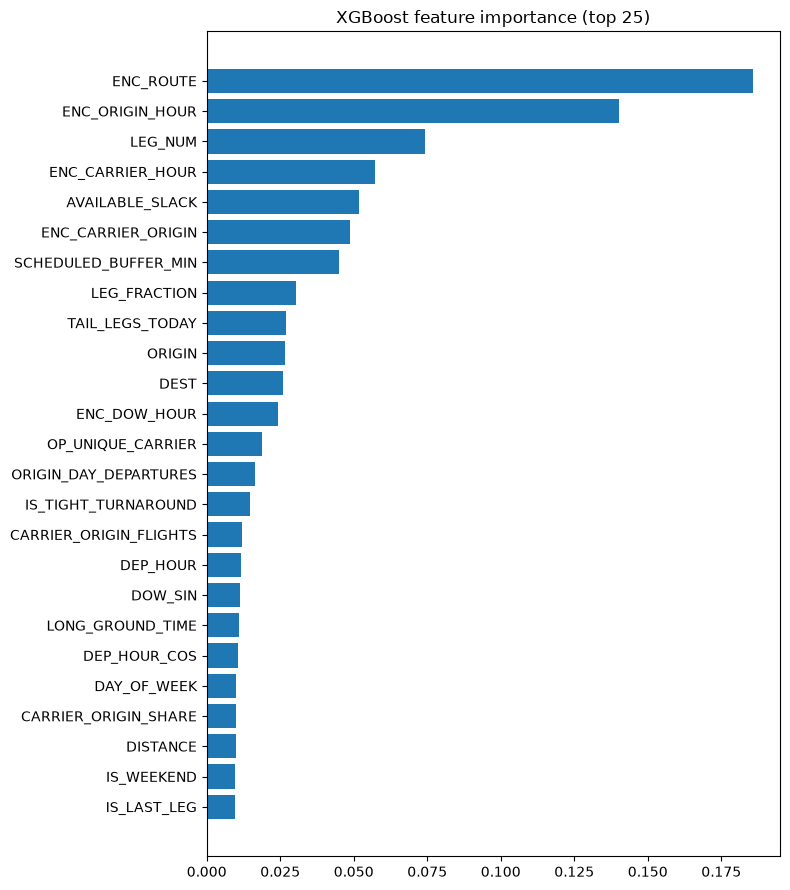

In [29]:
imp = pd.DataFrame({'feature': ALL_FEATURES, 'importance': xgb_m.feature_importances_})
imp = imp.sort_values('importance', ascending=False)
print(imp.to_string(index=False))

plt.figure(figsize=(8,9))
top = imp.head(25)
plt.barh(top['feature'][::-1], top['importance'][::-1])
plt.title('XGBoost feature importance (top 25)')
plt.tight_layout(); plt.show()

## 12 — Ranking performance

The number that decides whether the morning briefing is useful: how dense with real delays
is the top of the ranking?

In [30]:
best_prob = np.mean(parts, axis=0)   # blend

rows = []
for k in [0.5, 1, 2, 5, 10, 20]:
    n_k = max(int(len(best_prob)*k/100), 1)
    top = np.argsort(-best_prob)[:n_k]
    hits = int(np.asarray(y_test)[top].sum())
    rows.append({'top_k_pct': k, 'flights': n_k,
                 'precision': round(hits/n_k, 3),
                 'lift': round((hits/n_k)/base, 2),
                 'delays_caught': hits,
                 'pct_of_all_delays': round(100*hits/int(y_test.sum()), 1)})

print(f'Base rate: {base:.3f}\n')
print(pd.DataFrame(rows).to_string(index=False))

print('\nPer operating day, the top 1% is roughly what an OCC can actually review at 5am.')

Base rate: 0.156

 top_k_pct  flights  precision  lift  delays_caught  pct_of_all_delays
       0.5     1115      0.885  5.67            987                2.8
       1.0     2231      0.781  5.00           1742                5.0
       2.0     4462      0.611  3.92           2727                7.8
       5.0    11155      0.459  2.94           5115               14.7
      10.0    22310      0.374  2.39           8338               23.9
      20.0    44620      0.305  1.95          13601               39.1

Per operating day, the top 1% is roughly what an OCC can actually review at 5am.


## 13 — Threshold sweep

In [31]:
rows = []
for t in np.arange(0.30, 0.90, 0.05):
    pred = (best_prob >= t).astype(int)
    if pred.sum() == 0:
        continue
    rows.append({'threshold': round(t,2),
                 'precision': round(precision_score(y_test, pred, zero_division=0),3),
                 'recall': round(recall_score(y_test, pred),3),
                 'f1': round(f1_score(y_test, pred),3),
                 'flagged': int(pred.sum())})
sweep = pd.DataFrame(rows)
sweep['meets_6_1_targets'] = (sweep['precision']>=0.75) & (sweep['recall']>=0.70)
print(sweep.to_string(index=False))
ok = sweep[sweep['meets_6_1_targets']]
print('\nThresholds meeting both Section 6.1 targets:',
      list(ok['threshold']) if len(ok) else 'NONE')

 threshold  precision  recall    f1  flagged  meets_6_1_targets
      0.30      0.175   0.933 0.294   186150              False
      0.35      0.187   0.874 0.308   162813              False
      0.40      0.204   0.795 0.325   135690              False
      0.45      0.226   0.697 0.341   107432              False
      0.50      0.252   0.580 0.351    80183              False
      0.55      0.284   0.463 0.352    56854              False
      0.60      0.318   0.350 0.333    38278              False
      0.65      0.364   0.254 0.300    24314              False
      0.70      0.426   0.176 0.249    14380              False
      0.75      0.519   0.114 0.188     7678              False
      0.80      0.627   0.074 0.133     4124              False
      0.85      0.749   0.055 0.102     2541              False
      0.90      0.830   0.039 0.075     1656              False

Thresholds meeting both Section 6.1 targets: NONE


## 14 — Save results

In [32]:
import os
os.makedirs('results', exist_ok=True)
ablation.to_csv('results/feature_ablation.csv', index=False)
comparison.to_csv('results/model_comparison.csv', index=False)
imp.to_csv('results/feature_importance.csv', index=False)
xgb_m.save_model('results/xgb_primary_classifier.json')

print('Saved to results/')
print('\nHeadline for the report:')
best = comparison.iloc[0]
print(f"  Best model : {best['model']}")
print(f"  AUC        : {best['auc']}")
print(f"  p@1%       : {best['p@1%']}  ({round(best['p@1%']/base,2)}x lift)")
print(f"  F1         : {best['f1']}")

Saved to results/

Headline for the report:
  Best model : Blend (soft vote)
  AUC        : 0.6819
  p@1%       : 0.781  (5.0x lift)
  F1         : 0.351


In [33]:
top_n = int(len(best_prob) * 0.01)
top_idx = np.argsort(-best_prob)[:top_n]
top = test.iloc[top_idx]

print('Top 1% ranked flights:')
print(f'  had a late previous leg : {(top["PREV_ARR_DELAY"] > 0).mean():.1%}')
print(f'  continuous rotation     : {top["CONTINUOUS_ROTATION"].mean():.1%}')
print(f'  median available slack  : {top["AVAILABLE_SLACK"].median():.0f} min')
print(f'  median leg number       : {top["LEG_NUM"].median():.0f}')
print()
print('Whole test set for comparison:')
print(f'  had a late previous leg : {(test["PREV_ARR_DELAY"] > 0).mean():.1%}')
print(f'  median available slack  : {test["AVAILABLE_SLACK"].median():.0f} min')
print()
delayed_no_cause = ((test['DEP_DEL15']==1) & (test['ARR_DELAY'] < 15)).sum()
print(f'Departed 15+ late but arrived <15 late: {delayed_no_cause:,} '
      f'({100*delayed_no_cause/max((test["DEP_DEL15"]==1).sum(),1):.1f}% of delayed)')
print('These cannot have cause codes, so cascade-caused ones survived the primary filter.')

Top 1% ranked flights:
  had a late previous leg : 33.8%
  continuous rotation     : 40.6%
  median available slack  : 0 min
  median leg number       : 4

Whole test set for comparison:
  had a late previous leg : 20.0%
  median available slack  : 22 min

Departed 15+ late but arrived <15 late: 12,153 (34.9% of delayed)
These cannot have cause codes, so cascade-caused ones survived the primary filter.
